In [1]:
import os
import gc
import json
import math
import random
import warnings
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image, UnidentifiedImageError

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score,
    balanced_accuracy_score
)
from PIL import Image, ImageOps, ImageEnhance
import uuid
import os
import random
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

warnings.filterwarnings("ignore")
print("TensorFlow version:", tf.__version__)

2026-05-05 14:55:18.627332: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777992919.025864      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777992919.124015      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777992919.992749      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777992919.992824      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777992919.992830      57 computation_placer.cc:177] computation placer alr

TensorFlow version: 2.19.0


In [2]:
DATASET_DIR = "/kaggle/input/datasets/miramagdyfawzy/final-classification/FINAL_merged_filtered_for_translation"   

IMG_SIZE = 224
CHANNELS = 3
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

SEED = 42

# Warmup + fine-tuning
EPOCHS_HEAD = 15
EPOCHS_FINE = 30
LEARNING_RATE_HEAD = 1e-3
LEARNING_RATE_FINE = 2e-5

# Split proportions
TEST_SIZE = 0.15
VAL_SIZE = 0.15

# Model choice
# Options:
# "efficientnetv2b0", "efficientnetv2s", "resnet101v2", "densenet121", "glyphnet"
MODEL_NAME = "efficientnetv2b0"

# Imbalance handling
USE_CLASS_WEIGHTS = False
USE_AUGMENTATION = True
#USE_OVERSAMPLING = True
USE_MIXUP=True
# Remove classes with too few images.
MIN_SAMPLES_PER_CLASS = 4


OUTPUT_DIR = "/kaggle/working"
os.makedirs(OUTPUT_DIR, exist_ok=True)

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [3]:
IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp", ".tif", ".tiff"}

def is_valid_image(path):
    try:
        with Image.open(path) as img:
            img.verify()
        return True
    except (UnidentifiedImageError, OSError, IOError):
        return False

def scan_dataset(root_dir, verify_images=False):
    root = Path(root_dir)
    if not root.exists():
        raise FileNotFoundError(f"Dataset directory not found: {root_dir}")

    records = []
    class_dirs = sorted([p for p in root.iterdir() if p.is_dir()])

    if len(class_dirs) == 0:
        raise ValueError("No class folders found in DATASET_DIR.")

    for class_dir in class_dirs:
        class_name = class_dir.name
        for file_path in class_dir.rglob("*"):
            if file_path.suffix.lower() in IMAGE_EXTS:
                if verify_images and not is_valid_image(file_path):
                    continue
                records.append((str(file_path), class_name))

    df = pd.DataFrame(records, columns=["filepath", "label"])
    return df

df = scan_dataset(DATASET_DIR, verify_images=False)

print("Total images before filtering:", len(df))
print("Number of classes before filtering:", df["label"].nunique())
display(df.head())

Total images before filtering: 15847
Number of classes before filtering: 718


,filepath,label
0,/kaggle/input/datasets/miramagdyfawzy/final-cl...,A1
1,/kaggle/input/datasets/miramagdyfawzy/final-cl...,A1
2,/kaggle/input/datasets/miramagdyfawzy/final-cl...,A1
3,/kaggle/input/datasets/miramagdyfawzy/final-cl...,A1
4,/kaggle/input/datasets/miramagdyfawzy/final-cl...,A1


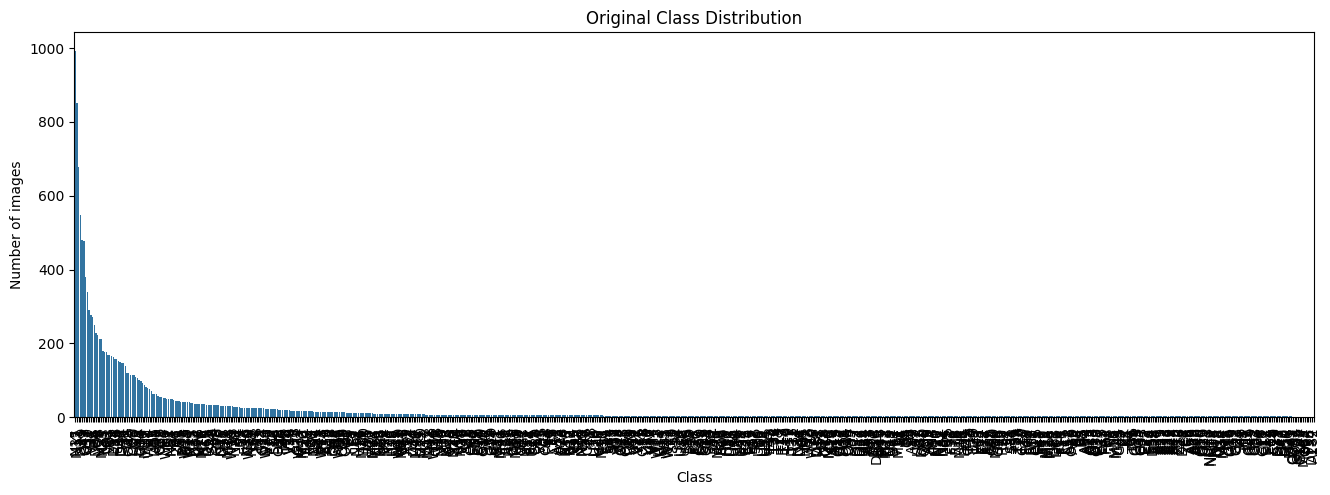

count    718.000000
mean      22.071031
std       74.310324
min        1.000000
25%        3.000000
50%        4.000000
75%        9.750000
max      993.000000
Name: count, dtype: float64


In [4]:
# original class distribution
orig_counts = df["label"].value_counts().sort_values(ascending=False)

plt.figure(figsize=(16, 5))
sns.barplot(x=orig_counts.index.astype(str), y=orig_counts.values)
plt.title("Original Class Distribution")
plt.xticks(rotation=90)
plt.ylabel("Number of images")
plt.xlabel("Class")
plt.show()

print(orig_counts.describe())

,samples_in_class,number_of_classes
0,1,13
1,2,143
2,3,127
3,4,129
4,5,48
...,...,...
92,481,1
93,548,1
94,678,1
95,850,1


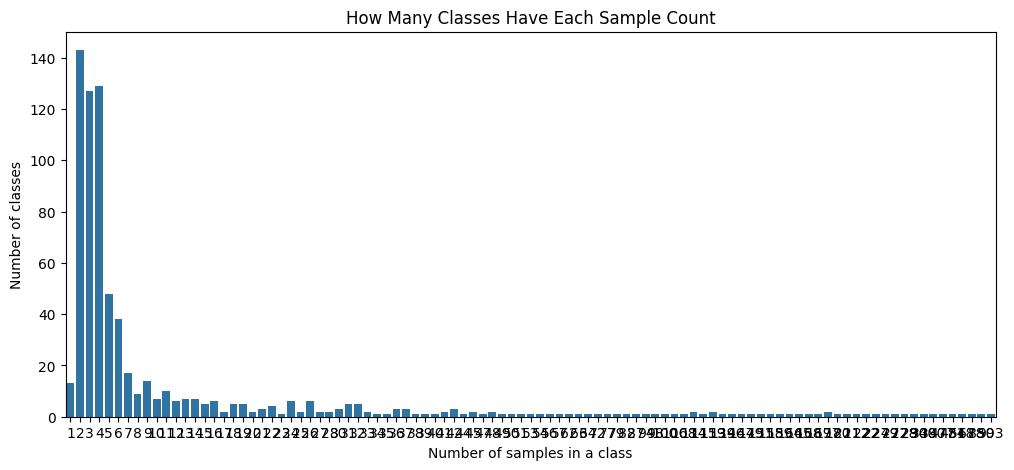

In [5]:
# HOW MANY CLASSES HAVE EACH COUNT

count_of_counts = df["label"].value_counts().value_counts().sort_index()

count_summary_df = pd.DataFrame({
    "samples_in_class": count_of_counts.index,
    "number_of_classes": count_of_counts.values
}).sort_values("samples_in_class")

display(count_summary_df)

plt.figure(figsize=(12, 5))
sns.barplot(data=count_summary_df, x="samples_in_class", y="number_of_classes")
plt.title("How Many Classes Have Each Sample Count")
plt.xlabel("Number of samples in a class")
plt.ylabel("Number of classes")
plt.show()

In [6]:
'''#Augment classes with 1 sample only 
from PIL import Image, ImageOps
import uuid
import os
import random

OUTPUT_AUG_DIR = "/kaggle/working/augmented"
os.makedirs(OUTPUT_AUG_DIR, exist_ok=True)

def augment_image(img):
    aug_type = random.choice(["flip", "rotate","contrast"])

    if aug_type == "flip":
        return ImageOps.mirror(img)
    elif aug_type == "rotate":
        return img.rotate(random.choice([10, -10]))
    elif aug_type == "contrast":
        return ImageOps.autocontrast(img)
    return img


new_records = []

class_counts = df["label"].value_counts()

for label, count in class_counts.items():
    if count < 3 :
        needed = 3 - count
        group = df[df["label"] == label]

        for _ in range(needed):
            row = group.sample(n=1, replace=True).iloc[0]
            img_path = row["filepath"]

            try:
                img = Image.open(img_path).convert("RGB")
                aug_img = augment_image(img)

                new_filename = f"{label}_{uuid.uuid4().hex}.png"
                new_path = os.path.join(OUTPUT_AUG_DIR, new_filename)

                aug_img.save(new_path)
                new_records.append((new_path, label))

            except Exception as e:
                print(f"Error processing {img_path}: {e}")
            
df_aug = pd.DataFrame(new_records, columns=["filepath", "label"])

df = pd.concat([df, df_aug], ignore_index=True)
class_counts = df["label"].value_counts()

print("Min samples after augmentation:", class_counts.min())
display(class_counts[class_counts < 3].sort_values())'''

'#Augment classes with 1 sample only \nfrom PIL import Image, ImageOps\nimport uuid\nimport os\nimport random\n\nOUTPUT_AUG_DIR = "/kaggle/working/augmented"\nos.makedirs(OUTPUT_AUG_DIR, exist_ok=True)\n\ndef augment_image(img):\n    aug_type = random.choice(["flip", "rotate","contrast"])\n\n    if aug_type == "flip":\n        return ImageOps.mirror(img)\n    elif aug_type == "rotate":\n        return img.rotate(random.choice([10, -10]))\n    elif aug_type == "contrast":\n        return ImageOps.autocontrast(img)\n    return img\n\n\nnew_records = []\n\nclass_counts = df["label"].value_counts()\n\nfor label, count in class_counts.items():\n    if count < 3 :\n        needed = 3 - count\n        group = df[df["label"] == label]\n\n        for _ in range(needed):\n            row = group.sample(n=1, replace=True).iloc[0]\n            img_path = row["filepath"]\n\n            try:\n                img = Image.open(img_path).convert("RGB")\n                aug_img = augment_image(img)\n\n 

In [7]:
class_counts = df["label"].value_counts()

classes_above = class_counts[class_counts >= MIN_SAMPLES_PER_CLASS]
print(f"Number of classes with more than {MIN_SAMPLES_PER_CLASS} samples:", len(classes_above))


Number of classes with more than 4 samples: 435


In [8]:
'''# Count samples per class
class_counts = df["label"].value_counts()

dfs = []

for label, group in df.groupby("label"):
    n = len(group)
    
    if n > 100:
        group_sampled = group.sample(n=100, random_state=SEED)
    else:
        group_sampled = group
    
    dfs.append(group_sampled)

# Combine all classes
df_filtered = pd.concat(dfs, ignore_index=True)

df_filtered = df_filtered.sample(frac=1.0, random_state=SEED).reset_index(drop=True)

print("Original number of classes:", df["label"].nunique())
print("Balanced number of classes:", df_filtered["label"].nunique())

print("Original dataset size:", len(df))
print("Balanced dataset size:", len(df_filtered))

print("\nNew class distribution:")
display(df_filtered["label"].value_counts().describe())'''

'# Count samples per class\nclass_counts = df["label"].value_counts()\n\ndfs = []\n\nfor label, group in df.groupby("label"):\n    n = len(group)\n    \n    if n > 100:\n        group_sampled = group.sample(n=100, random_state=SEED)\n    else:\n        group_sampled = group\n    \n    dfs.append(group_sampled)\n\n# Combine all classes\ndf_filtered = pd.concat(dfs, ignore_index=True)\n\ndf_filtered = df_filtered.sample(frac=1.0, random_state=SEED).reset_index(drop=True)\n\nprint("Original number of classes:", df["label"].nunique())\nprint("Balanced number of classes:", df_filtered["label"].nunique())\n\nprint("Original dataset size:", len(df))\nprint("Balanced dataset size:", len(df_filtered))\n\nprint("\nNew class distribution:")\ndisplay(df_filtered["label"].value_counts().describe())'

In [9]:
'''print(df_filtered["label"].value_counts().sort_values(ascending=False).head(10))'''

'print(df_filtered["label"].value_counts().sort_values(ascending=False).head(10))'

In [10]:

'''class_counts = df["label"].value_counts()


valid_classes = class_counts[class_counts <= 350].index

df_filtered = df[df["label"].isin(valid_classes)].reset_index(drop=True)

# Print results
print("Original number of classes:", df["label"].nunique())
print("Remaining classes:", df_filtered["label"].nunique())
print("Removed classes:", df["label"].nunique() - df_filtered["label"].nunique())

print("Original dataset size:", len(df))
print("Filtered dataset size:", len(df_filtered))'''

'class_counts = df["label"].value_counts()\n\n\nvalid_classes = class_counts[class_counts <= 350].index\n\ndf_filtered = df[df["label"].isin(valid_classes)].reset_index(drop=True)\n\n# Print results\nprint("Original number of classes:", df["label"].nunique())\nprint("Remaining classes:", df_filtered["label"].nunique())\nprint("Removed classes:", df["label"].nunique() - df_filtered["label"].nunique())\n\nprint("Original dataset size:", len(df))\nprint("Filtered dataset size:", len(df_filtered))'

In [11]:
# FILTER ULTRA-RARE CLASSES

class_counts = df["label"].value_counts()

valid_classes = class_counts[class_counts >= MIN_SAMPLES_PER_CLASS].index.tolist()
removed_classes = class_counts[class_counts < MIN_SAMPLES_PER_CLASS].index.tolist()

df_filtered = df[df["label"].isin(valid_classes)].reset_index(drop=True)

print(f"MIN_SAMPLES_PER_CLASS = {MIN_SAMPLES_PER_CLASS}")
print("Classes kept   :", len(valid_classes))
print("Classes removed:", len(removed_classes))
print("Images before  :", len(df))
print("Images after   :", len(df_filtered))

print("\nRemoved classes and their counts:")
display(class_counts[class_counts < MIN_SAMPLES_PER_CLASS].sort_values())

print("\nKept class distribution:")
display(df_filtered["label"].value_counts().sort_values(ascending=False).head(20))

MIN_SAMPLES_PER_CLASS = 4
Classes kept   : 435
Classes removed: 283
Images before  : 15847
Images after   : 15167

Removed classes and their counts:


label
A282    1
D154    1
P36     1
P13     1
O64     1
       ..
Q4      3
D53     3
M27     3
M31     3
V12     3
Name: count, Length: 283, dtype: int64


Kept class distribution:


label
N35    993
M17    850
X1     678
D21    548
S29    481
I9     477
G43    380
G17    340
V30    290
D4     278
V31    272
R8     249
D36    227
Q3     222
V28    212
M23    211
N33    180
F35    177
Q1     177
A1     169
Name: count, dtype: int64

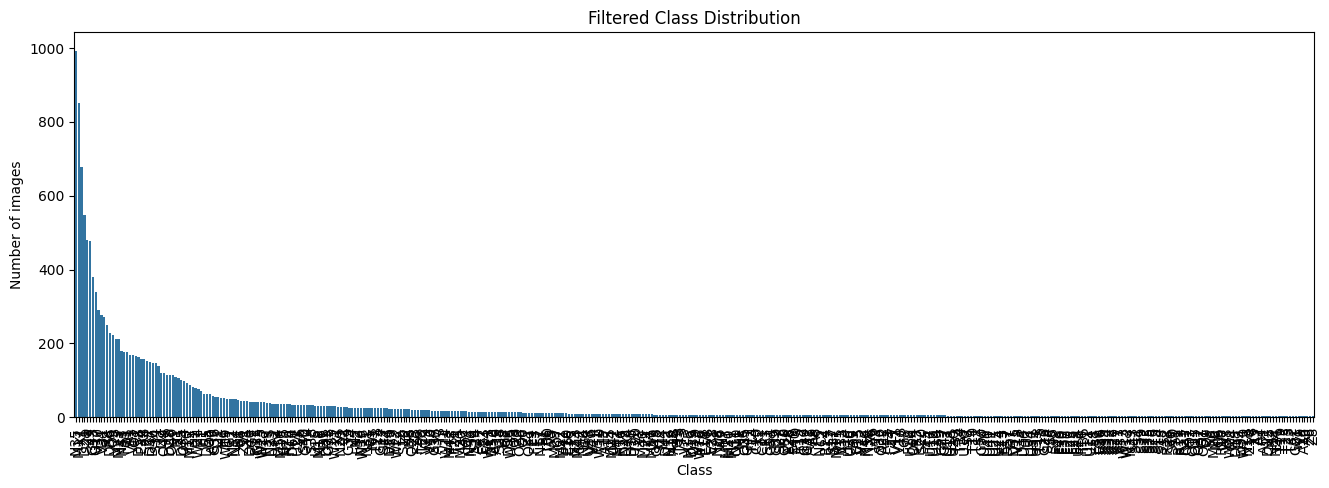

count    435.000000
mean      34.866667
std       93.307137
min        4.000000
25%        4.000000
50%        7.000000
75%       24.000000
max      993.000000
Name: count, dtype: float64


In [12]:
# FILTERED CLASS DISTRIBUTION

filtered_counts = df_filtered["label"].value_counts().sort_values(ascending=False)

plt.figure(figsize=(16, 5))
sns.barplot(x=filtered_counts.index.astype(str), y=filtered_counts.values)
plt.title("Filtered Class Distribution")
plt.xticks(rotation=90)
plt.ylabel("Number of images")
plt.xlabel("Class")
plt.show()

print(filtered_counts.describe())

## Label encoding

In [13]:
# LABEL ENCODING AFTER FILTERING


class_names = sorted(df_filtered["label"].unique().tolist())
class_to_idx = {c: i for i, c in enumerate(class_names)}
idx_to_class = {i: c for c, i in class_to_idx.items()}

df_filtered["label_idx"] = df_filtered["label"].map(class_to_idx)

NUM_CLASSES = len(class_names)

print("Number of classes after filtering:", NUM_CLASSES)
display(df_filtered.head())

Number of classes after filtering: 435


,filepath,label,label_idx
0,/kaggle/input/datasets/miramagdyfawzy/final-cl...,A1,0
1,/kaggle/input/datasets/miramagdyfawzy/final-cl...,A1,0
2,/kaggle/input/datasets/miramagdyfawzy/final-cl...,A1,0
3,/kaggle/input/datasets/miramagdyfawzy/final-cl...,A1,0
4,/kaggle/input/datasets/miramagdyfawzy/final-cl...,A1,0


In [14]:
#Customized split
train_rows = []
val_rows = []
test_rows = []

for label, group in df_filtered.groupby("label"):

    group = group.sample(frac=1.0, random_state=SEED).reset_index(drop=True)
    n = len(group)

     # =========================
    # CASE 1: EXACTLY 3 SAMPLES
    # =========================
    if n == 3:
        train_rows.append(group.iloc[:1])
        val_rows.append(group.iloc[1:2])
        test_rows.append(group.iloc[2:3])

    # =========================
    # CASE 2: MORE THAN 3 SAMPLES
    # =========================
    elif n > 3:
        train_end = int(0.7 * n)
        val_end = int(0.85 * n)

        # safety: ensure at least 1 sample in val/test
        train_end = max(1, train_end)
        val_end = max(train_end + 1, val_end)

        train_rows.append(group.iloc[:train_end])
        val_rows.append(group.iloc[train_end:val_end])
        test_rows.append(group.iloc[val_end:])

    # =========================
    # CASE 3: 1 or 2 samples (rare edge case safety)
    # =========================
    elif n == 2:
        train_rows.append(group.iloc[:1])
        val_rows.append(group.iloc[1:2])

    elif n == 1:
        train_rows.append(group)

# FINAL DATASETS
train_df = pd.concat(train_rows, ignore_index=True)
val_df   = pd.concat(val_rows, ignore_index=True)
test_df  = pd.concat(test_rows, ignore_index=True)

# SHUFFLE
train_df = train_df.sample(frac=1.0, random_state=SEED).reset_index(drop=True)
val_df   = val_df.sample(frac=1.0, random_state=SEED).reset_index(drop=True)
test_df  = test_df.sample(frac=1.0, random_state=SEED).reset_index(drop=True)


print("Train classes:", train_df["label"].nunique())
print("Val classes:", val_df["label"].nunique())
print("Test classes:", test_df["label"].nunique())

Train classes: 435
Val classes: 435
Test classes: 435


In [15]:
print("Unique classes in df_filtered:", df_filtered["label"].nunique())

Unique classes in df_filtered: 435


In [16]:
'''class_counts = df_filtered["label"].value_counts()
small_classes = class_counts[class_counts <6 ].index

forced_train = []
forced_val = []
forced_test = []

remaining_rows = []

for label, group in df_filtered.groupby("label"):
    if label in small_classes:
        group = group.sample(frac=1.0, random_state=SEED).reset_index(drop=True)

        # Force 1 sample per split
        forced_train.append(group.iloc[0])
        forced_val.append(group.iloc[1])
        forced_test.append(group.iloc[2])
    else:
        remaining_rows.append(group)

forced_train_df = pd.DataFrame(forced_train)
forced_val_df = pd.DataFrame(forced_val)
forced_test_df = pd.DataFrame(forced_test)

remaining_df = pd.concat(remaining_rows, ignore_index=True)

remaining_df["label_idx"] = remaining_df["label"].map(class_to_idx)
forced_train_df["label_idx"] = forced_train_df["label"].map(class_to_idx)
forced_val_df["label_idx"]   = forced_val_df["label"].map(class_to_idx)
forced_test_df["label_idx"]  = forced_test_df["label"].map(class_to_idx)'''

'class_counts = df_filtered["label"].value_counts()\nsmall_classes = class_counts[class_counts <6 ].index\n\nforced_train = []\nforced_val = []\nforced_test = []\n\nremaining_rows = []\n\nfor label, group in df_filtered.groupby("label"):\n    if label in small_classes:\n        group = group.sample(frac=1.0, random_state=SEED).reset_index(drop=True)\n\n        # Force 1 sample per split\n        forced_train.append(group.iloc[0])\n        forced_val.append(group.iloc[1])\n        forced_test.append(group.iloc[2])\n    else:\n        remaining_rows.append(group)\n\nforced_train_df = pd.DataFrame(forced_train)\nforced_val_df = pd.DataFrame(forced_val)\nforced_test_df = pd.DataFrame(forced_test)\n\nremaining_df = pd.concat(remaining_rows, ignore_index=True)\n\nremaining_df["label_idx"] = remaining_df["label"].map(class_to_idx)\nforced_train_df["label_idx"] = forced_train_df["label"].map(class_to_idx)\nforced_val_df["label_idx"]   = forced_val_df["label"].map(class_to_idx)\nforced_test_df[

In [17]:
'''# STRATIFIED SPLIT

trainval_df, test_df = train_test_split(
    remaining_df,
    test_size=TEST_SIZE,
    stratify=remaining_df["label_idx"],
    random_state=SEED
)


val_relative = VAL_SIZE / (1.0 - TEST_SIZE)

train_df, val_df = train_test_split(
    trainval_df,
    test_size=val_relative,
    stratify=trainval_df["label_idx"],
    random_state=SEED
)
train_df = pd.concat([train_df, forced_train_df], ignore_index=True)
val_df   = pd.concat([val_df, forced_val_df], ignore_index=True)
test_df  = pd.concat([test_df, forced_test_df], ignore_index=True)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("Train:", len(train_df))
print("Val  :", len(val_df))
print("Test :", len(test_df))

print("\nTrain class counts:")
display(train_df["label"].value_counts().sort_values())'''

'# STRATIFIED SPLIT\n\ntrainval_df, test_df = train_test_split(\n    remaining_df,\n    test_size=TEST_SIZE,\n    stratify=remaining_df["label_idx"],\n    random_state=SEED\n)\n\n\nval_relative = VAL_SIZE / (1.0 - TEST_SIZE)\n\ntrain_df, val_df = train_test_split(\n    trainval_df,\n    test_size=val_relative,\n    stratify=trainval_df["label_idx"],\n    random_state=SEED\n)\ntrain_df = pd.concat([train_df, forced_train_df], ignore_index=True)\nval_df   = pd.concat([val_df, forced_val_df], ignore_index=True)\ntest_df  = pd.concat([test_df, forced_test_df], ignore_index=True)\n\ntrain_df = train_df.reset_index(drop=True)\nval_df = val_df.reset_index(drop=True)\ntest_df = test_df.reset_index(drop=True)\n\nprint("Train:", len(train_df))\nprint("Val  :", len(val_df))\nprint("Test :", len(test_df))\n\nprint("\nTrain class counts:")\ndisplay(train_df["label"].value_counts().sort_values())'

In [18]:

OUTPUT_AUG_DIR = "/kaggle/working/augmented"
os.makedirs(OUTPUT_AUG_DIR, exist_ok=True)

def augment_image(img):
    ops = [
        lambda x: ImageOps.mirror(x),
        lambda x: x.rotate(random.uniform(-15, 15)),
        lambda x: ImageEnhance.Contrast(x).enhance(random.uniform(0.7, 1.3)),
        lambda x: ImageEnhance.Brightness(x).enhance(random.uniform(0.7, 1.3)),
    ]
    
    op = random.choice(ops)
    return op(img)

In [19]:
def augment_to_range(df_in, min_target=50, max_target=150):
    new_records = []
    dfs = []

    for label, group in df_in.groupby("label"):
        n = len(group)

        # =========================
        # CASE 1: TOO SMALL → AUGMENT
        # =========================
        if n < min_target:
            target_size = random.randint(min_target, max_target)
            needed = target_size - n

            print(f"Augmenting class {label}: {n} → {target_size}")

            for _ in range(needed):
                row = group.sample(n=1, replace=True).iloc[0]
                img_path = row["filepath"]

                try:
                    img = Image.open(img_path).convert("RGB")
                    aug_img = augment_image(img)

                    new_filename = f"{label}_{uuid.uuid4().hex}.png"
                    new_path = os.path.join(OUTPUT_AUG_DIR, new_filename)

                    aug_img.save(new_path)
                    new_records.append((new_path, label))

                except Exception as e:
                    print(f"Error: {e}")

            dfs.append(group)

        # =========================
        # CASE 2: TOO LARGE → DOWNSAMPLE
        # =========================
        elif n > max_target:
            print(f"Downsampling class {label}: {n} → {max_target}")
            group = group.sample(n=max_target, random_state=SEED)
            dfs.append(group)

        # =========================
        # CASE 3: GOOD RANGE → KEEP
        # =========================
        else:
            dfs.append(group)

    df_aug = pd.DataFrame(new_records, columns=["filepath", "label"])
    df_out = pd.concat(dfs + [df_aug], ignore_index=True)

    df_out = df_out.sample(frac=1.0, random_state=SEED).reset_index(drop=True)

    return df_out

In [20]:
train_df_balanced = augment_to_range(train_df, 50, 150)

# Re-map label_idx (important after adding new rows)
train_df_balanced["label_idx"] = train_df_balanced["label"].map(class_to_idx)

print("\nTrain class counts (AFTER balancing):")
display(train_df_balanced["label"].value_counts().sort_values())

counts = train_df_balanced["label"].value_counts()

print("Min samples:", counts.min())
print("Max samples:", counts.max())
print(counts.describe())

Augmenting class A14: 3 → 131
Augmenting class A15: 4 → 124
Augmenting class A16: 2 → 65
Augmenting class A17: 6 → 141
Augmenting class A19: 9 → 150
Augmenting class A2: 25 → 107
Augmenting class A24: 10 → 144
Augmenting class A26: 4 → 82
Augmenting class A28: 4 → 141
Augmenting class A3: 2 → 110
Augmenting class A30: 12 → 125
Augmenting class A4: 2 → 129
Augmenting class A40: 39 → 122
Augmenting class A42: 11 → 136
Augmenting class A50: 9 → 109
Augmenting class A51: 2 → 138
Augmenting class A55: 3 → 140
Augmenting class A6: 3 → 138
Augmenting class A7: 2 → 146
Augmenting class A9: 3 → 70
Augmenting class AA1: 3 → 142
Augmenting class B1: 32 → 106
Augmenting class C10: 4 → 51
Augmenting class C11: 4 → 78
Augmenting class C2: 3 → 111
Augmenting class D1: 21 → 145
Augmenting class D10: 5 → 88
Augmenting class D12: 2 → 137
Augmenting class D18: 2 → 85
Augmenting class D19: 4 → 106
Downsampling class D21: 383 → 150
Augmenting class D3: 2 → 64
Augmenting class D34: 2 → 53
Downsampling class

label
O27     50
G36     50
F1      50
D38     50
S23     50
      ... 
R8     150
Q3     150
D21    150
S29    150
I9     150
Name: count, Length: 435, dtype: int64

Min samples: 50
Max samples: 150
count    435.000000
mean     102.770115
std       29.939532
min       50.000000
25%       78.000000
50%      104.000000
75%      129.000000
max      150.000000
Name: count, dtype: float64


In [21]:
'''def oversample_to_range(df_in, min_target=250, max_target=350):
    dfs = []

    for label, group in df_in.groupby("label"):
        n = len(group)

        # Decide target size
        if n < min_target:
            target_size = random.randint(min_target, max_target)
        else:
            target_size = n  # keep as is

        # Oversample if needed
        if target_size > n:
            extra = group.sample(n=target_size - n, replace=True, random_state=SEED)
            group_balanced = pd.concat([group, extra], ignore_index=True)
        else:
            group_balanced = group

        dfs.append(group_balanced)

    df_out = pd.concat(dfs, ignore_index=True)
    df_out = df_out.sample(frac=1.0, random_state=SEED).reset_index(drop=True)

    return df_out

if USE_OVERSAMPLING:
    train_df_balanced = oversample_to_range(train_df, 250, 350)
else:
    train_df_balanced = train_df.copy()

print("Original training size :", len(train_df))
print("Balanced training size :", len(train_df_balanced))

print("\nOriginal train counts:")
display(train_df["label"].value_counts().sort_values())

print("\nBalanced train counts:")
display(train_df_balanced["label"].value_counts().sort_values())'''

'def oversample_to_range(df_in, min_target=250, max_target=350):\n    dfs = []\n\n    for label, group in df_in.groupby("label"):\n        n = len(group)\n\n        # Decide target size\n        if n < min_target:\n            target_size = random.randint(min_target, max_target)\n        else:\n            target_size = n  # keep as is\n\n        # Oversample if needed\n        if target_size > n:\n            extra = group.sample(n=target_size - n, replace=True, random_state=SEED)\n            group_balanced = pd.concat([group, extra], ignore_index=True)\n        else:\n            group_balanced = group\n\n        dfs.append(group_balanced)\n\n    df_out = pd.concat(dfs, ignore_index=True)\n    df_out = df_out.sample(frac=1.0, random_state=SEED).reset_index(drop=True)\n\n    return df_out\n\nif USE_OVERSAMPLING:\n    train_df_balanced = oversample_to_range(train_df, 250, 350)\nelse:\n    train_df_balanced = train_df.copy()\n\nprint("Original training size :", len(train_df))\nprint("B

In [22]:
'''# OVERSAMPLE TRAINING DATA ONLY

def oversample_dataframe(df_in):
    max_count = df_in["label"].value_counts().max()

    dfs = []
    for label, group in df_in.groupby("label"):
        n = len(group)
        repeat_factor = max_count // n
        remainder = max_count % n

        repeated = pd.concat([group] * repeat_factor, ignore_index=True)

        if remainder > 0:
            extra = group.sample(n=remainder, replace=True, random_state=SEED)
            repeated = pd.concat([repeated, extra], ignore_index=True)

        dfs.append(repeated)

    df_out = pd.concat(dfs, ignore_index=True)
    df_out = df_out.sample(frac=1.0, random_state=SEED).reset_index(drop=True)
    return df_out

if USE_OVERSAMPLING:
    train_df_balanced = oversample_dataframe(train_df)
else:
    train_df_balanced = train_df.copy()

print("Original training size :", len(train_df))
print("Balanced training size :", len(train_df_balanced))

print("\nOriginal train counts:")
display(train_df["label"].value_counts().sort_values())

print("\nBalanced train counts:")
display(train_df_balanced["label"].value_counts().sort_values())'''

'# OVERSAMPLE TRAINING DATA ONLY\n\ndef oversample_dataframe(df_in):\n    max_count = df_in["label"].value_counts().max()\n\n    dfs = []\n    for label, group in df_in.groupby("label"):\n        n = len(group)\n        repeat_factor = max_count // n\n        remainder = max_count % n\n\n        repeated = pd.concat([group] * repeat_factor, ignore_index=True)\n\n        if remainder > 0:\n            extra = group.sample(n=remainder, replace=True, random_state=SEED)\n            repeated = pd.concat([repeated, extra], ignore_index=True)\n\n        dfs.append(repeated)\n\n    df_out = pd.concat(dfs, ignore_index=True)\n    df_out = df_out.sample(frac=1.0, random_state=SEED).reset_index(drop=True)\n    return df_out\n\nif USE_OVERSAMPLING:\n    train_df_balanced = oversample_dataframe(train_df)\nelse:\n    train_df_balanced = train_df.copy()\n\nprint("Original training size :", len(train_df))\nprint("Balanced training size :", len(train_df_balanced))\n\nprint("\nOriginal train counts:")\

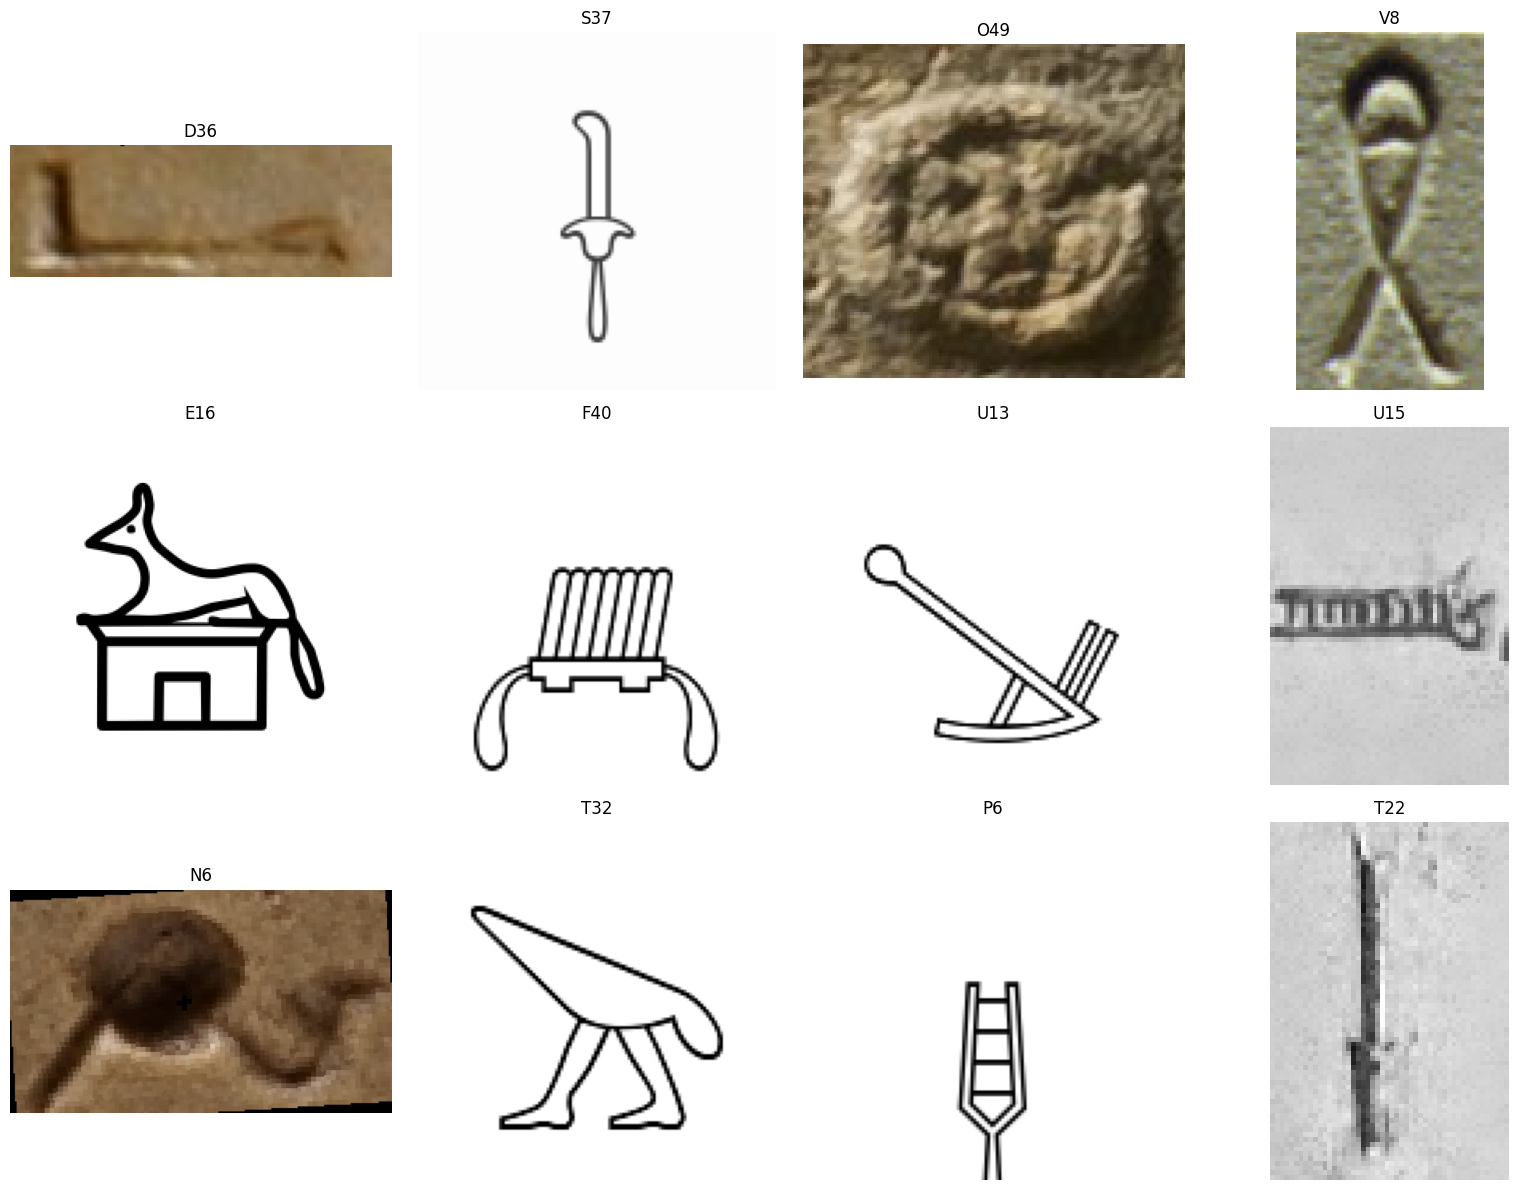

In [23]:
# SHOW SAMPLE IMAGES

def show_samples(df_subset, n=12, cols=4):
    sample_df = df_subset.sample(min(n, len(df_subset)), random_state=SEED)
    rows = math.ceil(len(sample_df) / cols)

    plt.figure(figsize=(4 * cols, 4 * rows))
    for i, (_, row) in enumerate(sample_df.iterrows(), start=1):
        plt.subplot(rows, cols, i)
        img = Image.open(row["filepath"]).convert("RGB")
        plt.imshow(img)
        plt.title(row["label"])
        plt.axis("off")
    plt.tight_layout()
    plt.show()

show_samples(train_df_balanced, n=12, cols=4)

In [24]:
'''train_paths = train_df_balanced["filepath"].values
train_labels = train_df_balanced["label_idx"].values

val_paths = val_df["filepath"].values
val_labels = val_df["label_idx"].values

test_paths = test_df["filepath"].values
test_labels = test_df["label_idx"].values

NUM_CLASSES = len(class_names)

def decode_and_resize(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_image(img, channels=CHANNELS, expand_animations=False)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img = tf.cast(img, tf.float32)
    return img, tf.cast(label, tf.int32)

data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.15),           # was 0.08
    layers.RandomZoom(0.20),               # was 0.15
    layers.RandomTranslation(0.10, 0.10),  # was 0.08
    layers.RandomContrast(0.20),           # was 0.15
    layers.RandomBrightness(0.15),         # NEW
], name="augmentation")

def make_dataset(paths, labels, training=False):
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if training:
        ds = ds.shuffle(buffer_size=len(paths), seed=SEED)

    ds = ds.map(decode_and_resize, num_parallel_calls=AUTOTUNE)

    if training and USE_AUGMENTATION:
        ds = ds.map(lambda x, y: (data_augmentation(x, training=True), y),
                    num_parallel_calls=AUTOTUNE)

    ds = ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)
    return ds

train_ds = make_dataset(train_paths, train_labels, training=True)
val_ds = make_dataset(val_paths, val_labels, training=False)
test_ds = make_dataset(test_paths, test_labels, training=False)

print(train_ds)'''

'train_paths = train_df_balanced["filepath"].values\ntrain_labels = train_df_balanced["label_idx"].values\n\nval_paths = val_df["filepath"].values\nval_labels = val_df["label_idx"].values\n\ntest_paths = test_df["filepath"].values\ntest_labels = test_df["label_idx"].values\n\nNUM_CLASSES = len(class_names)\n\ndef decode_and_resize(path, label):\n    img = tf.io.read_file(path)\n    img = tf.image.decode_image(img, channels=CHANNELS, expand_animations=False)\n    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])\n    img = tf.cast(img, tf.float32)\n    return img, tf.cast(label, tf.int32)\n\ndata_augmentation = keras.Sequential([\n    layers.RandomFlip("horizontal_and_vertical"),\n    layers.RandomRotation(0.15),           # was 0.08\n    layers.RandomZoom(0.20),               # was 0.15\n    layers.RandomTranslation(0.10, 0.10),  # was 0.08\n    layers.RandomContrast(0.20),           # was 0.15\n    layers.RandomBrightness(0.15),         # NEW\n], name="augmentation")\n\ndef make_datase

In [25]:
train_paths = train_df_balanced["filepath"].values
train_labels = train_df_balanced["label_idx"].values

val_paths = val_df["filepath"].values
val_labels = val_df["label_idx"].values

test_paths = test_df["filepath"].values
test_labels = test_df["label_idx"].values

NUM_CLASSES = len(class_names)

def decode_and_resize(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_image(img, channels=CHANNELS, expand_animations=False)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img = tf.cast(img, tf.float32)
    return img, tf.cast(label, tf.int32)

data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.08),           # was 0.08
    layers.RandomZoom(0.10),               # was 0.15
    layers.RandomTranslation(0.05,0.05),  # was 0.08
    layers.RandomContrast(0.20),     # was 0.15
    layers.RandomBrightness(0.10),
], name="augmentation")

def mixup(images, labels, alpha=0.3):
    images = tf.cast(images, tf.float32)
    labels = tf.cast(labels, tf.float32)

    batch_size = tf.shape(images)[0]

    lam = tf.random.uniform([], 0, 1)
    lam = tf.maximum(lam, 1 - lam)

    idx = tf.random.shuffle(tf.range(batch_size))

    mixed_images = lam * images + (1 - lam) * tf.gather(images, idx)
    mixed_labels = lam * labels + (1 - lam) * tf.gather(labels, idx)

    return mixed_images, mixed_labels
    
def make_dataset(paths, labels, training=False):
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))

    if training:
        ds = ds.shuffle(buffer_size=len(paths), seed=SEED)

    ds = ds.map(decode_and_resize, num_parallel_calls=AUTOTUNE)

    # ✅ Convert labels to one-hot ALWAYS (not just mixup)
    ds = ds.map(lambda x, y: (x, tf.one_hot(y, NUM_CLASSES)),
                num_parallel_calls=AUTOTUNE)
    
    if training and USE_AUGMENTATION:
        ds = ds.map(lambda x, y: (data_augmentation(x, training=True), y),
                    num_parallel_calls=AUTOTUNE)
    
    ds = ds.batch(BATCH_SIZE)

    if training and USE_MIXUP:
        ds = ds.map(lambda x, y: mixup(x, y, alpha=0.3),
                    num_parallel_calls=AUTOTUNE)
        
    ds = ds.prefetch(AUTOTUNE)
    return ds

train_ds = make_dataset(train_paths, train_labels, training=True)
val_ds = make_dataset(val_paths, val_labels, training=False)
test_ds = make_dataset(test_paths, test_labels, training=False)

print(train_ds)

I0000 00:00:1777993344.957051      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1777993344.963102      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 435), dtype=tf.float32, name=None))>


In [26]:
print("Unique labels in TRAIN:", len(np.unique(train_labels)))
print("Unique labels in VAL  :", len(np.unique(val_labels)))
print("Unique labels in TEST :", len(np.unique(test_labels)))

Unique labels in TRAIN: 435
Unique labels in VAL  : 435
Unique labels in TEST : 435


In [27]:
missing = set(range(NUM_CLASSES)) - set(np.unique(train_labels))
print("Missing classes in train:", len(missing))

Missing classes in train: 0


In [28]:
def get_preprocess_and_backbone(model_name, img_size):
    model_name = model_name.lower()

    if model_name == "efficientnetv2b0":
        preprocess = tf.keras.applications.efficientnet_v2.preprocess_input
        backbone = tf.keras.applications.EfficientNetV2B0(
            include_top=False,
            weights="imagenet",
            input_shape=(img_size, img_size, 3)
        )
        feature_dim = 1280

    elif model_name == "efficientnetv2s":
        preprocess = tf.keras.applications.efficientnet_v2.preprocess_input
        backbone = tf.keras.applications.EfficientNetV2S(
            include_top=False,
            weights="imagenet",
            input_shape=(img_size, img_size, 3)
        )
        feature_dim = 1280

    elif model_name == "resnet101v2":
        preprocess = tf.keras.applications.resnet_v2.preprocess_input
        backbone = tf.keras.applications.ResNet101V2(
            include_top=False,
            weights="imagenet",
            input_shape=(img_size, img_size, 3)
        )
        feature_dim = 2048

    elif model_name == "densenet121":
        preprocess = tf.keras.applications.densenet.preprocess_input
        backbone = tf.keras.applications.DenseNet121(
            include_top=False,
            weights="imagenet",
            input_shape=(img_size, img_size, 3)
        )
        feature_dim = 1024

    else:
        raise ValueError(f"Unsupported transfer model: {model_name}")

    return preprocess, backbone, feature_dim

In [29]:
'''# =========================
# 10) BUILD MODEL
# =========================

def build_model(model_name, num_classes, img_size=224):
    model_name = model_name.lower()

    #if model_name == "glyphnet":
        model = build_glyphnet_style(
            input_shape=(img_size, img_size, 3),
            num_classes=num_classes
        )
        backbone = None
     #   return model, backbone

    preprocess, backbone, feature_dim = get_preprocess_and_backbone(model_name, img_size)

    inputs = keras.Input(shape=(img_size, img_size, 3))
    x = preprocess(inputs)
    x = backbone(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.30)(x)
    x = layers.Dense(256, activation="relu")(x)
    x = layers.Dropout(0.25)(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)

    model = keras.Model(inputs, outputs, name=model_name)
    return model, backbone'''

'# =========================\n# 10) BUILD MODEL\n# =========================\n\ndef build_model(model_name, num_classes, img_size=224):\n    model_name = model_name.lower()\n\n    #if model_name == "glyphnet":\n        model = build_glyphnet_style(\n            input_shape=(img_size, img_size, 3),\n            num_classes=num_classes\n        )\n        backbone = None\n     #   return model, backbone\n\n    preprocess, backbone, feature_dim = get_preprocess_and_backbone(model_name, img_size)\n\n    inputs = keras.Input(shape=(img_size, img_size, 3))\n    x = preprocess(inputs)\n    x = backbone(x, training=False)\n    x = layers.GlobalAveragePooling2D()(x)\n    x = layers.Dropout(0.30)(x)\n    x = layers.Dense(256, activation="relu")(x)\n    x = layers.Dropout(0.25)(x)\n    outputs = layers.Dense(num_classes, activation="softmax")(x)\n\n    model = keras.Model(inputs, outputs, name=model_name)\n    return model, backbone'

In [30]:
def build_model(model_name, num_classes, img_size=224):
    model_name = model_name.lower()
    preprocess, backbone, feature_dim = get_preprocess_and_backbone(model_name, img_size) 
    inputs = keras.Input(shape=(img_size, img_size, 3))
    x = preprocess(inputs) 
    #x = backbone(x, training=False) 
    x = backbone(x)
    x = layers.GlobalAveragePooling2D()(x) # ✅ NEW HEAD 
    x = layers.BatchNormalization()(x) 
    x = layers.Dropout(0.25)(x) 
    x = layers.Dense( 512, activation="relu", kernel_regularizer=keras.regularizers.l2(1e-4) )(x) 
    x = layers.Dropout(0.2)(x) 
    outputs = layers.Dense(num_classes, activation="softmax",dtype="float32")(x) 
    model = keras.Model(inputs, outputs, name=model_name) 
    return model, backbone

In [31]:
# Mixed precision can speed up Kaggle GPU training
try:
    from tensorflow.keras import mixed_precision
    mixed_precision.set_global_policy("mixed_float16")
    print("Mixed precision enabled.")
except Exception as e:
    print("Could not enable mixed precision:", e)

def get_callbacks(run_name):
    ckpt_path = os.path.join(OUTPUT_DIR, f"{run_name}_best.keras")

    callbacks = [
        keras.callbacks.ModelCheckpoint(
            ckpt_path,
            monitor="val_categorical_accuracy",
            save_best_only=True,
            mode="max",
            verbose=1
        ),
        keras.callbacks.EarlyStopping(
            monitor="val_categorical_accuracy",
            patience=5,
            mode="max",
            restore_best_weights=True,
            verbose=1
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,     # ✅ updated
            patience=4,     # ✅ updated
            min_lr=1e-7,
            verbose=1
        ),
        keras.callbacks.CSVLogger(
            os.path.join(OUTPUT_DIR, f"{run_name}_training_log.csv")
        )
    ]
    return callbacks

if USE_CLASS_WEIGHTS:
    classes_for_weights = np.unique(train_labels)
    weights = compute_class_weight(
        class_weight="balanced",
        classes=classes_for_weights,
        y=train_labels
    )
    class_weight_dict = {int(c): float(w) for c, w in zip(classes_for_weights, weights)}
else:
    class_weight_dict = None

print("Class weights:", class_weight_dict if class_weight_dict else "Not used")

Mixed precision enabled.
Class weights: Not used


In [32]:
'''def compile_model(model, lr):
    optimizer = keras.optimizers.Adam(learning_rate=lr)
    model.compile(
        optimizer=optimizer,
        loss="sparse_categorical_crossentropy",
        metrics=[
            keras.metrics.SparseCategoricalAccuracy(name="categorical_accuracy")
        ]
    )'''

def compile_model(model, lr):
    optimizer = keras.optimizers.Adam(learning_rate=lr, clipnorm=1.0)

    model.compile(
        optimizer=optimizer,
        loss=keras.losses.CategoricalCrossentropy(),
        metrics=[
            keras.metrics.CategoricalAccuracy(name="categorical_accuracy")
        ]
    )
    
def plot_history(history, title="Training History"):
    hist = pd.DataFrame(history.history)

    plt.figure(figsize=(14, 5))

    plt.subplot(1, 2, 1)
    plt.plot(hist["loss"], label="train_loss")
    plt.plot(hist["val_loss"], label="val_loss")
    plt.title(f"{title} - Loss")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(hist["categorical_accuracy"], label="train_acc")
    plt.plot(hist["val_categorical_accuracy"], label="val_acc")
    plt.title(f"{title} - Accuracy")
    plt.legend()

    plt.show()

def train_model(model_name, train_ds, val_ds, num_classes, img_size):
    run_name = f"{model_name}_img{img_size}"
    print(f"\n========== TRAINING: {run_name} ==========\n")

    model, backbone = build_model(model_name, num_classes, img_size)

    print(model.summary())

    # Stage 1: frozen backbone for transfer models
    if backbone is not None:
        backbone.trainable = False
        compile_model(model, LEARNING_RATE_HEAD)

        history_head = model.fit(
            train_ds,
            validation_data=val_ds,
            epochs=EPOCHS_HEAD,
            callbacks=get_callbacks(run_name + "_head"),
            class_weight=class_weight_dict,
            verbose=1
        )

        plot_history(history_head, title=f"{run_name} - Head Training")
        print("\nFinal Head Training Metrics:")
        print("Train Loss:", history_head.history["loss"][-1])
        print("Train Acc :", history_head.history["categorical_accuracy"][-1])
        print("Val Loss  :", history_head.history["val_loss"][-1])
        print("Val Acc   :", history_head.history["val_categorical_accuracy"][-1])

        # Stage 2: fine-tune
        backbone.trainable = True
        unfreeze_from = int(len(backbone.layers) * 0.6)
        for layer in backbone.layers[:unfreeze_from]:
            layer.trainable = False
        
        for layer in backbone.layers[unfreeze_from:]:
            layer.trainable = True
        
        # optional: freeze earliest layers if you want
        # for layer in backbone.layers[:len(backbone.layers)//3]:
        #     layer.trainable = False

        compile_model(model, LEARNING_RATE_FINE)

        history_fine = model.fit(
            train_ds,
            validation_data=val_ds,
            epochs=EPOCHS_FINE,
            callbacks=get_callbacks(run_name + "_fine"),
            class_weight=class_weight_dict,
            verbose=1
        )

        plot_history(history_fine, title=f"{run_name} - Fine Tuning")
        print("\nFinal Fine-Tuning Metrics:")
        print("Train Loss:", history_fine.history["loss"][-1])
        print("Train Acc :", history_fine.history["categorical_accuracy"][-1])
        print("Val Loss  :", history_fine.history["val_loss"][-1])
        print("Val Acc   :", history_fine.history["val_categorical_accuracy"][-1])
        
        print("\nBest Validation Metrics:")
        print("Best Val Acc :", max(history_fine.history["val_categorical_accuracy"]))
        print("Best Val Loss:", min(history_fine.history["val_loss"]))
        
        '''else:
        # GlyphNet-style training from scratch
        compile_model(model, LEARNING_RATE_HEAD)

        history_scratch = model.fit(
            train_ds,
            validation_data=val_ds,
            epochs=EPOCHS_HEAD + EPOCHS_FINE,
            callbacks=get_callbacks(run_name),
            class_weight=class_weight_dict,
            verbose=1
        )

        plot_history(history_scratch, title=f"{run_name} - Training")'''

    return model


========== TRAINING: efficientnetv2b0_img224 ==========

24274472/24274472 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "efficientnetv2b0"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetv2-b0 (Functional)  │ (None, 7, 7, 1280)     │     5,919,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       655,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 435)            │       223,155 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,803,459 (25.95 MB)

 Trainable params: 6,740,291 (25.71 MB)

 Non-trainable params: 63,168 (246.75 KB)

None
Epoch 1/15


I0000 00:00:1777993364.492005     138 service.cc:152] XLA service 0x79ed140188c0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1777993364.492047     138 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1777993364.492052     138 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1777993368.101759     138 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1777993391.207049     138 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1398/1398 ━━━━━━━━━━━━━━━━━━━━ 0s 236ms/step - categorical_accuracy: 0.1894 - loss: 5.0529
Epoch 1: val_categorical_accuracy improved from -inf to 0.42222, saving model to /kaggle/working/efficientnetv2b0_img224_head_best.keras
1398/1398 ━━━━━━━━━━━━━━━━━━━━ 412s 260ms/step - categorical_accuracy: 0.1895 - loss: 5.0524 - val_categorical_accuracy: 0.4222 - val_loss: 2.6367 - learning_rate: 0.0010
Epoch 2/15
1397/1398 ━━━━━━━━━━━━━━━━━━━━ 0s 222ms/step - categorical_accuracy: 0.4007 - loss: 3.6850
Epoch 2: val_categorical_accuracy improved from 0.42222 to 0.47094, saving model to /kaggle/working/efficientnetv2b0_img224_head_best.keras
1398/1398 ━━━━━━━━━━━━━━━━━━━━ 313s 224ms/step - categorical_accuracy: 0.4007 - loss: 3.6849 - val_categorical_accuracy: 0.4709 - val_loss: 2.4473 - learning_rate: 0.0010
Epoch 3/15
1397/1398 ━━━━━━━━━━━━━━━━━━━━ 0s 221ms/step - categorical_accuracy: 0.4447 - loss: 3.5396
Epoch 3: val_categorical_accuracy improved from 0.47094 to 0.49145, saving model to /k

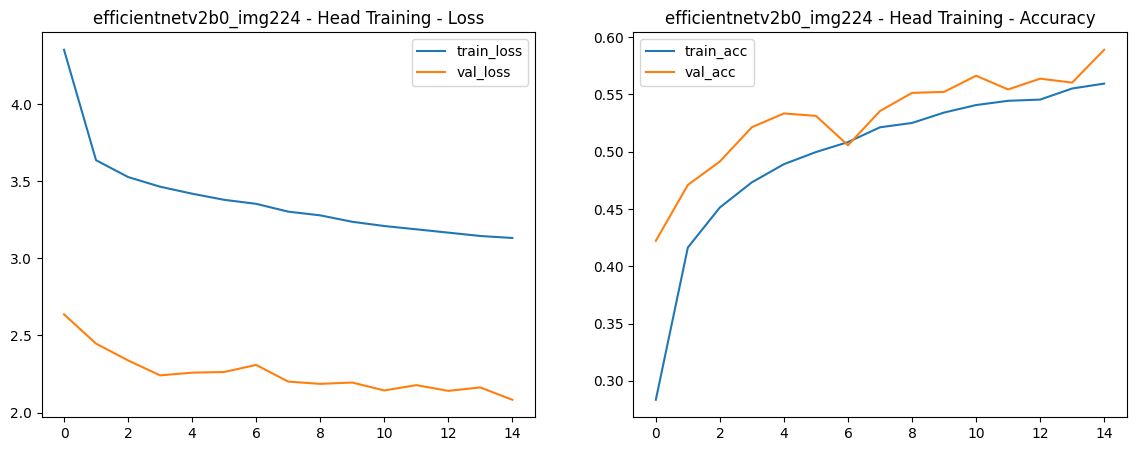


Final Head Training Metrics:
Train Loss: 3.1316893100738525
Train Acc : 0.5593781471252441
Val Loss  : 2.0834462642669678
Val Acc   : 0.5888888835906982
Epoch 1/30
1398/1398 ━━━━━━━━━━━━━━━━━━━━ 0s 252ms/step - categorical_accuracy: 0.4788 - loss: 3.5193
Epoch 1: val_categorical_accuracy improved from -inf to 0.60897, saving model to /kaggle/working/efficientnetv2b0_img224_fine_best.keras
1398/1398 ━━━━━━━━━━━━━━━━━━━━ 456s 272ms/step - categorical_accuracy: 0.4788 - loss: 3.5192 - val_categorical_accuracy: 0.6090 - val_loss: 1.9952 - learning_rate: 2.0000e-05
Epoch 2/30
1397/1398 ━━━━━━━━━━━━━━━━━━━━ 0s 224ms/step - categorical_accuracy: 0.5883 - loss: 3.0681
Epoch 2: val_categorical_accuracy improved from 0.60897 to 0.63077, saving model to /kaggle/working/efficientnetv2b0_img224_fine_best.keras
1398/1398 ━━━━━━━━━━━━━━━━━━━━ 316s 226ms/step - categorical_accuracy: 0.5883 - loss: 3.0680 - val_categorical_accuracy: 0.6308 - val_loss: 1.8960 - learning_rate: 2.0000e-05
Epoch 3/30
1397

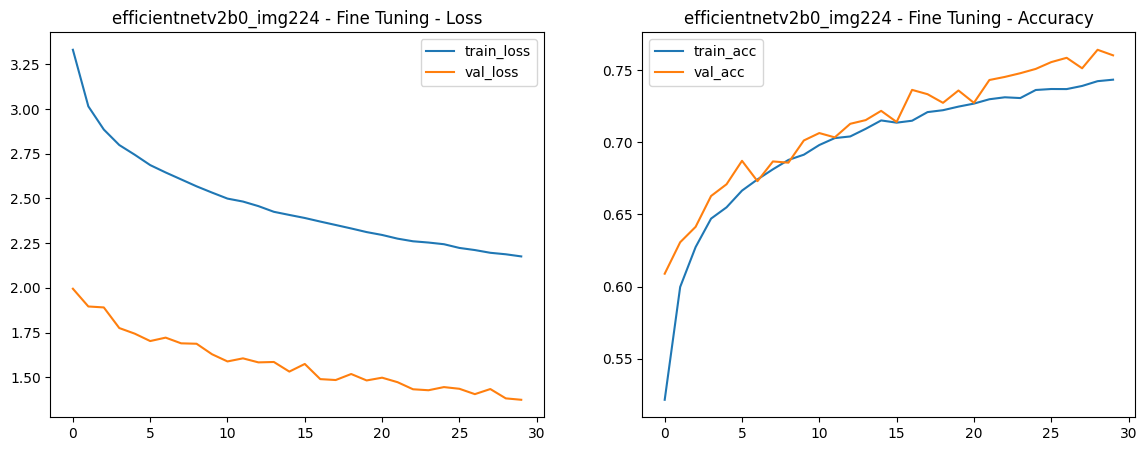


Final Fine-Tuning Metrics:
Train Loss: 2.1759395599365234
Train Acc : 0.7433844208717346
Val Loss  : 1.3742965459823608
Val Acc   : 0.7602564096450806

Best Validation Metrics:
Best Val Acc : 0.764102578163147
Best Val Loss: 1.3742965459823608


In [33]:
model = train_model(
    model_name=MODEL_NAME,
    train_ds=train_ds,
    val_ds=val_ds,
    num_classes=NUM_CLASSES,
    img_size=IMG_SIZE
)

In [35]:
'''from tensorflow import keras

checkpoint_path = "/kaggle/working/efficientnetv2b0_img224_fine_best.keras"

model = keras.models.load_model(checkpoint_path)
LEARNING_RATE_FINE = 2e-5
compile_model(model, LEARNING_RATE_FINE)'''

'from tensorflow import keras\n\ncheckpoint_path = "/kaggle/working/efficientnetv2b0_img224_fine_best.keras"\n\nmodel = keras.models.load_model(checkpoint_path)\nLEARNING_RATE_FINE = 2e-5\ncompile_model(model, LEARNING_RATE_FINE)'

In [36]:
'''history_resume = model.fit(
    train_ds,
    validation_data=val_ds,
    initial_epoch=4,
    epochs=25,
    callbacks=get_callbacks("resume_fine"),
    verbose=1
)'''

'history_resume = model.fit(\n    train_ds,\n    validation_data=val_ds,\n    initial_epoch=4,\n    epochs=25,\n    callbacks=get_callbacks("resume_fine"),\n    verbose=1\n)'

In [37]:
'''best_resume_path = "/kaggle/working/resume_fine_best.keras"
model = keras.models.load_model(best_resume_path)'''

'best_resume_path = "/kaggle/working/resume_fine_best.keras"\nmodel = keras.models.load_model(best_resume_path)'

In [38]:
final_model_path = os.path.join(OUTPUT_DIR, f"{MODEL_NAME}_final.keras")
model.save(final_model_path)

label_map_path = os.path.join(OUTPUT_DIR, "label_map.json")
with open(label_map_path, "w") as f:
    json.dump(idx_to_class, f, indent=2)

print("Saved model to:", final_model_path)
print("Saved label map to:", label_map_path)

Saved model to: /kaggle/working/efficientnetv2b0_final.keras
Saved label map to: /kaggle/working/label_map.json


Loaded best model from: /kaggle/working/efficientnetv2b0_img224_fine_best.keras
Recompiled with LR = 5e-06
Epoch 1/20
1398/1398 ━━━━━━━━━━━━━━━━━━━━ 0s 250ms/step - categorical_accuracy: 0.7425 - loss: 2.1741
Epoch 1: val_categorical_accuracy improved from -inf to 0.76111, saving model to /kaggle/working/stage3_lowlr_best.keras
1398/1398 ━━━━━━━━━━━━━━━━━━━━ 448s 269ms/step - categorical_accuracy: 0.7425 - loss: 2.1741 - val_categorical_accuracy: 0.7611 - val_loss: 1.3933 - learning_rate: 5.0000e-06
Epoch 2/20
1397/1398 ━━━━━━━━━━━━━━━━━━━━ 0s 226ms/step - categorical_accuracy: 0.7421 - loss: 2.1764
Epoch 2: val_categorical_accuracy did not improve from 0.76111
1398/1398 ━━━━━━━━━━━━━━━━━━━━ 317s 227ms/step - categorical_accuracy: 0.7421 - loss: 2.1764 - val_categorical_accuracy: 0.7577 - val_loss: 1.4058 - learning_rate: 5.0000e-06
Epoch 3/20
1397/1398 ━━━━━━━━━━━━━━━━━━━━ 0s 225ms/step - categorical_accuracy: 0.7429 - loss: 2.1678
Epoch 3: val_categorical_accuracy did not improve fro

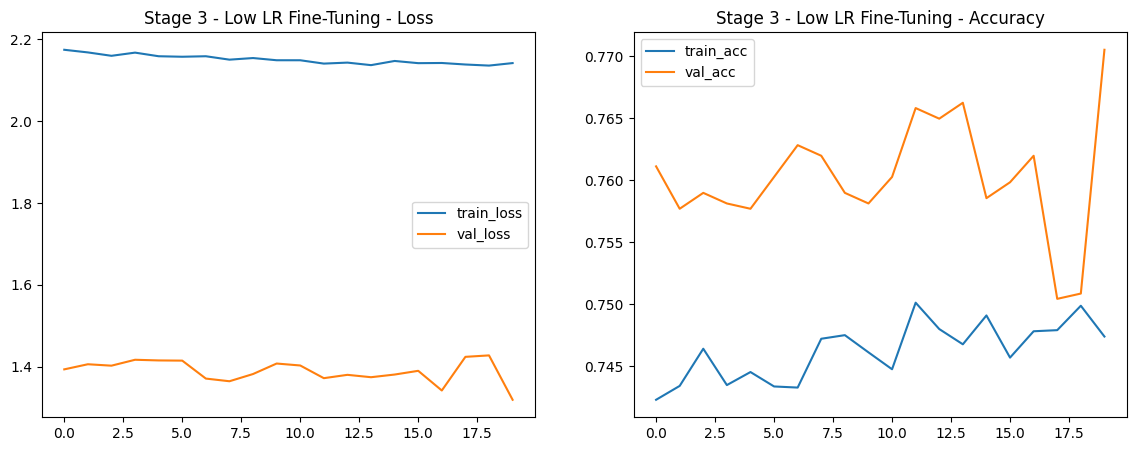


STAGE 3 RESULTS
Final Train Accuracy: 0.7474
Final Train Loss    : 2.1421
------------------------------
Best Val Accuracy   : 0.7705
Best Val Loss       : 1.3190
Stage 3 best model loaded from: /kaggle/working/stage3_lowlr_best.keras


In [39]:
# ============================================================
# STAGE 3: RESUME WITH LOWER LR (after 25-epoch fine run)
# ============================================================

# --- Step 1: Load the best model from your completed fine-tuning run ---
best_model_path = "/kaggle/working/efficientnetv2b0_img224_fine_best.keras"
model = keras.models.load_model(best_model_path)
print("Loaded best model from:", best_model_path)



# --- Step 2: Recompile with lower LR ---
LEARNING_RATE_STAGE3 = 5e-6  # half of previous 2e-5
compile_model(model, LEARNING_RATE_STAGE3)
print(f"Recompiled with LR = {LEARNING_RATE_STAGE3}")

# --- Step 3: Custom callbacks for this stage ---
def get_callbacks_stage3(run_name):
    ckpt_path = os.path.join(OUTPUT_DIR, f"{run_name}_best.keras")
    return [
        keras.callbacks.ModelCheckpoint(
            ckpt_path,
            monitor="val_categorical_accuracy",
            save_best_only=True,
            mode="max",
            verbose=1
        ),
        keras.callbacks.EarlyStopping(
            monitor="val_categorical_accuracy",
            patience=7,          # more patient — LR is low, changes are slow
            mode="max",
            restore_best_weights=True,
            verbose=1
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=3,          # tighter — squeeze out gains faster
            min_lr=1e-8,
            verbose=1
        ),
        keras.callbacks.CSVLogger(
            os.path.join(OUTPUT_DIR, f"{run_name}_log.csv")
        )
    ]

# --- Step 4: Train stage 3 ---
history_stage3 = model.fit(
    train_ds,
    validation_data=val_ds, 
    epochs=20,          # up to 20 more epochs (early stopping will cut if needed)
    callbacks=get_callbacks_stage3("stage3_lowlr"),
    verbose=1
)

plot_history(history_stage3, title="Stage 3 - Low LR Fine-Tuning")

print("\n" + "="*30)
print("STAGE 3 RESULTS")
print("="*30)

# Extracting metrics from history
final_train_acc = history_stage3.history["categorical_accuracy"][-1]
final_train_loss = history_stage3.history["loss"][-1]
best_val_acc = max(history_stage3.history["val_categorical_accuracy"])
best_val_loss = min(history_stage3.history["val_loss"])

print(f"Final Train Accuracy: {final_train_acc:.4f}")
print(f"Final Train Loss    : {final_train_loss:.4f}")
print("-" * 30)
print(f"Best Val Accuracy   : {best_val_acc:.4f}")
print(f"Best Val Loss       : {best_val_loss:.4f}")
print("="*30)

# --- Step 5: Save best stage 3 model ---
best_stage3_path = "/kaggle/working/stage3_lowlr_best.keras"
model_stage3 = keras.models.load_model(best_stage3_path)
print("Stage 3 best model loaded from:", best_stage3_path)


In [41]:
def predict_dataset(model, ds):
    probs = model.predict(ds, verbose=1)
    preds = np.argmax(probs, axis=1)
    return probs, preds

test_probs, test_preds = predict_dataset(model, test_ds)

test_true = test_labels

test_acc = accuracy_score(test_true, test_preds)
test_f1_macro = f1_score(test_true, test_preds, average="macro")
test_bal_acc = balanced_accuracy_score(test_true, test_preds)

print(f"Test Accuracy         : {test_acc:.4f}")
print(f"Test Macro F1         : {test_f1_macro:.4f}")
print(f"Test Balanced Accuracy: {test_bal_acc:.4f}")

77/77 ━━━━━━━━━━━━━━━━━━━━ 47s 417ms/step
Test Accuracy         : 0.7593
Test Macro F1         : 0.6205
Test Balanced Accuracy: 0.6737


In [41]:
'''import shutil

shutil.make_archive(
    '//kaggle/working/augmented',
    'zip',
    '/kaggle/working/augmented'
)'''

"import shutil\n\nshutil.make_archive(\n    '//kaggle/working/augmented',\n    'zip',\n    '/kaggle/working/augmented'\n)"

In [42]:
report = classification_report(
    test_true,
    test_preds,
    target_names=class_names,
    digits=4
)

print(report)

              precision    recall  f1-score   support

          A1     0.7917    0.7308    0.7600        26
         A14     1.0000    1.0000    1.0000         1
         A15     1.0000    1.0000    1.0000         1
         A16     0.0000    0.0000    0.0000         1
         A17     0.0000    0.0000    0.0000         2
         A19     0.6000    1.0000    0.7500         3
          A2     0.4000    0.3333    0.3636         6
         A24     1.0000    0.3333    0.5000         3
         A26     0.0000    0.0000    0.0000         1
         A28     0.3333    0.5000    0.4000         2
          A3     0.0000    0.0000    0.0000         1
         A30     0.4000    0.6667    0.5000         3
          A4     0.0000    0.0000    0.0000         1
         A40     0.5000    0.7778    0.6087         9
         A42     0.0000    0.0000    0.0000         3
         A50     0.7500    1.0000    0.8571         3
         A51     0.0000    0.0000    0.0000         1
         A55     0.0000    

In [43]:
'''report = classification_report(
    test_true,
    test_preds,
    digits=4
)

print(report)'''

'report = classification_report(\n    test_true,\n    test_preds,\n    digits=4\n)\n\nprint(report)'

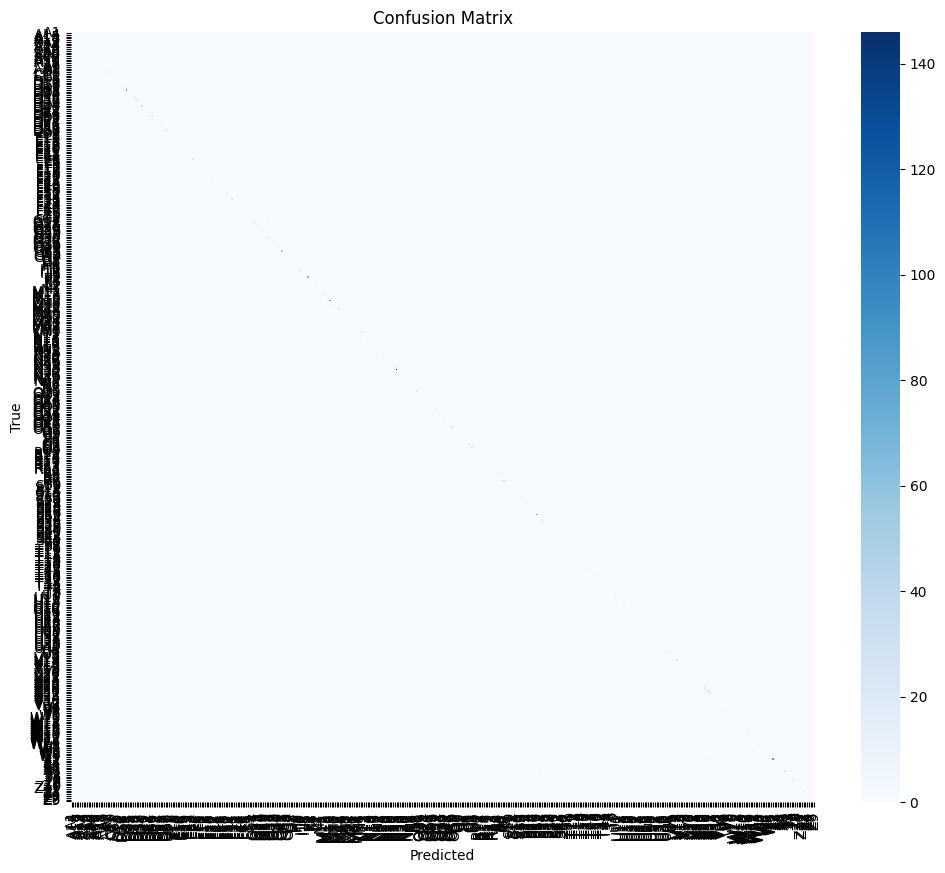

In [44]:
cm = confusion_matrix(test_true, test_preds)

plt.figure(figsize=(12, 10))
sns.heatmap(cm, cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

Wrong predictions: 591


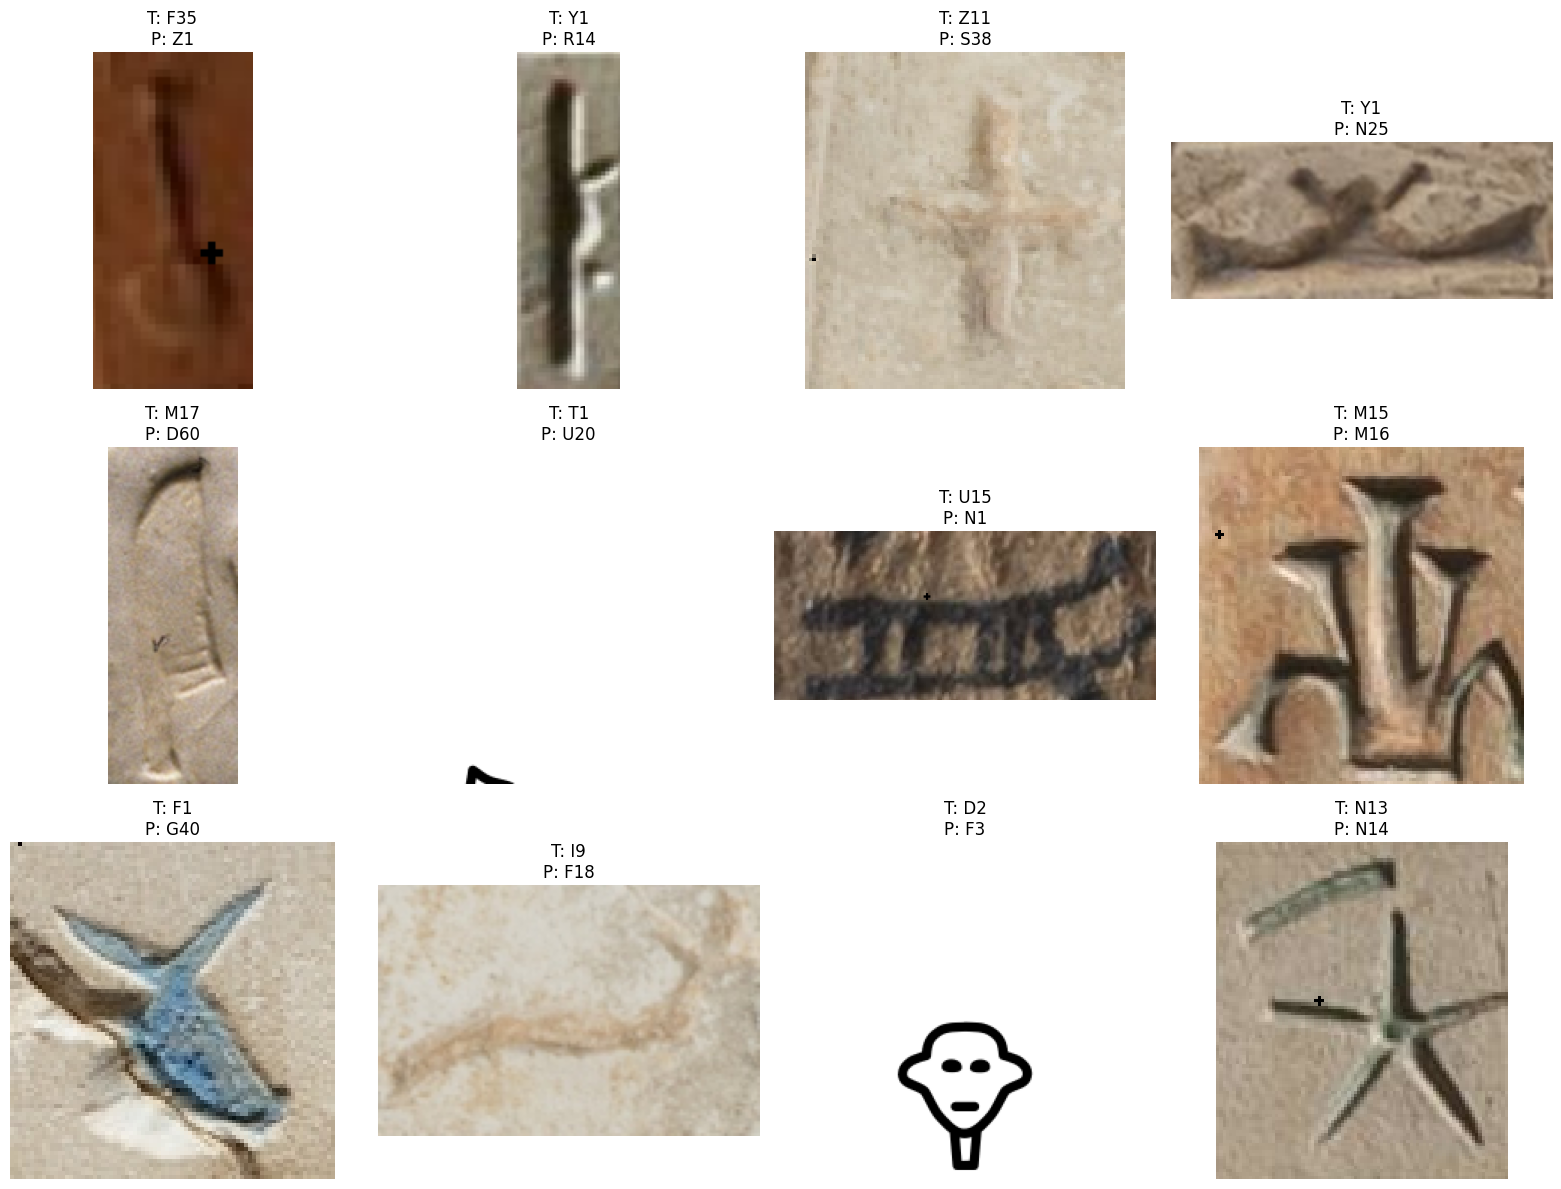

In [45]:
test_results_df = test_df.copy()
test_results_df["pred_idx"] = test_preds
test_results_df["pred_label"] = test_results_df["pred_idx"].map(idx_to_class)
test_results_df["correct"] = test_results_df["label"] == test_results_df["pred_label"]

wrong_df = test_results_df[~test_results_df["correct"]].copy()
print("Wrong predictions:", len(wrong_df))

def show_wrong_predictions(df_wrong, n=12, cols=4):
    if len(df_wrong) == 0:
        print("No wrong predictions to display.")
        return

    sample_df = df_wrong.sample(min(n, len(df_wrong)), random_state=SEED)
    rows = math.ceil(len(sample_df) / cols)

    plt.figure(figsize=(4 * cols, 4 * rows))
    for i, (_, row) in enumerate(sample_df.iterrows(), start=1):
        plt.subplot(rows, cols, i)
        img = Image.open(row["filepath"]).convert("RGB")
        plt.imshow(img)
        plt.title(f"T: {row['label']}\nP: {row['pred_label']}")
        plt.axis("off")
    plt.tight_layout()
    plt.show()

show_wrong_predictions(wrong_df, n=12, cols=4)

In [46]:
'''final_model_path = os.path.join(OUTPUT_DIR, f"{MODEL_NAME}_final.keras")
model.save(final_model_path)

label_map_path = os.path.join(OUTPUT_DIR, "label_map.json")
with open(label_map_path, "w") as f:
    json.dump(idx_to_class, f, indent=2)

print("Saved model to:", final_model_path)
print("Saved label map to:", label_map_path)'''

'final_model_path = os.path.join(OUTPUT_DIR, f"{MODEL_NAME}_final.keras")\nmodel.save(final_model_path)\n\nlabel_map_path = os.path.join(OUTPUT_DIR, "label_map.json")\nwith open(label_map_path, "w") as f:\n    json.dump(idx_to_class, f, indent=2)\n\nprint("Saved model to:", final_model_path)\nprint("Saved label map to:", label_map_path)'

In [47]:
def load_and_prepare_image(image_path, img_size=224):
    img = Image.open(image_path).convert("RGB")
    img = img.resize((img_size, img_size))
    arr = np.array(img).astype(np.float32)
    arr = np.expand_dims(arr, axis=0)
    return img, arr

def predict_single_image(model, image_path, idx_to_class, img_size=224, top_k=5):
    pil_img, arr = load_and_prepare_image(image_path, img_size)
    probs = model.predict(arr, verbose=0)[0]
    top_indices = np.argsort(probs)[::-1][:top_k]

    plt.figure(figsize=(5, 5))
    plt.imshow(pil_img)
    plt.axis("off")
    plt.title("Input image")
    plt.show()

    print("Top predictions:")
    for idx in top_indices:
        print(f"{idx_to_class[str(idx)] if isinstance(list(idx_to_class.keys())[0], str) else idx_to_class[idx]} : {probs[idx]:.4f}")

In [48]:
# Example:
# sample_image = test_df.iloc[0]["filepath"]
# predict_single_image(model, sample_image, idx_to_class, img_size=IMG_SIZE, top_k=5)

In [49]:
# =========================
# 20) INFERENCE ON A WHOLE FOLDER
# =========================

def predict_folder(model, folder_path, idx_to_class, img_size=224):
    folder = Path(folder_path)
    image_paths = [str(p) for p in folder.rglob("*") if p.suffix.lower() in IMAGE_EXTS]

    results = []
    for path in image_paths:
        try:
            _, arr = load_and_prepare_image(path, img_size)
            probs = model.predict(arr, verbose=0)[0]
            pred_idx = int(np.argmax(probs))
            pred_label = idx_to_class[str(pred_idx)] if isinstance(list(idx_to_class.keys())[0], str) else idx_to_class[pred_idx]
            conf = float(np.max(probs))
            results.append([path, pred_idx, pred_label, conf])
        except Exception as e:
            results.append([path, None, "ERROR", None])

    results_df = pd.DataFrame(results, columns=["filepath", "pred_idx", "pred_label", "confidence"])
    return results_df

# Example:
# unlabeled_results = predict_folder(model, "/kaggle/input/some-unlabeled-folder", idx_to_class, img_size=IMG_SIZE)
# display(unlabeled_results.head())
# unlabeled_results.to_csv("/kaggle/working/unlabeled_predictions.csv", index=False)